# 03b — Preprocessing v2 (Spatial Block Split)

Input: `data/processed/dataset_v2.csv`

Changes vs v1:
- Uses elevation-stratified negative samples
- Adds **spatial block IDs** (20 km UTM grid)
- `GroupShuffleSplit` ensures no spatial block leaks between train/test

Outputs: `train_v2.csv`, `test_v2.csv`, `scaler_v2.pkl`, `encoder_v2.pkl`, `selected_features_v2.json`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

RANDOM_STATE   = 42
VIF_THRESHOLD  = 10.0
CORR_THRESHOLD = 0.85
TEST_SIZE      = 0.30
BLOCK_SIZE_M   = 20_000  # 20 km spatial blocks

df = pd.read_csv(PROCESSED / 'dataset_v2.csv')
print(f'Loaded dataset_v2: {df.shape}')
print(f'Class balance: {df.label.mean():.4f}')

Loaded dataset_v2: (72296, 24)
Class balance: 0.5000


## 1. Missing Value Imputation

In [2]:
pop_median = df['population_density'].median()
df['population_density'] = df['population_density'].fillna(pop_median)
print(f'population_density: filled NaN with median={pop_median:.4f}')
assert df.isnull().sum().sum() == 0, 'Unexpected NaN remaining'
print('No remaining NaN values.')

population_density: filled NaN with median=0.9901
No remaining NaN values.


## 2. Spatial Distribution of Samples

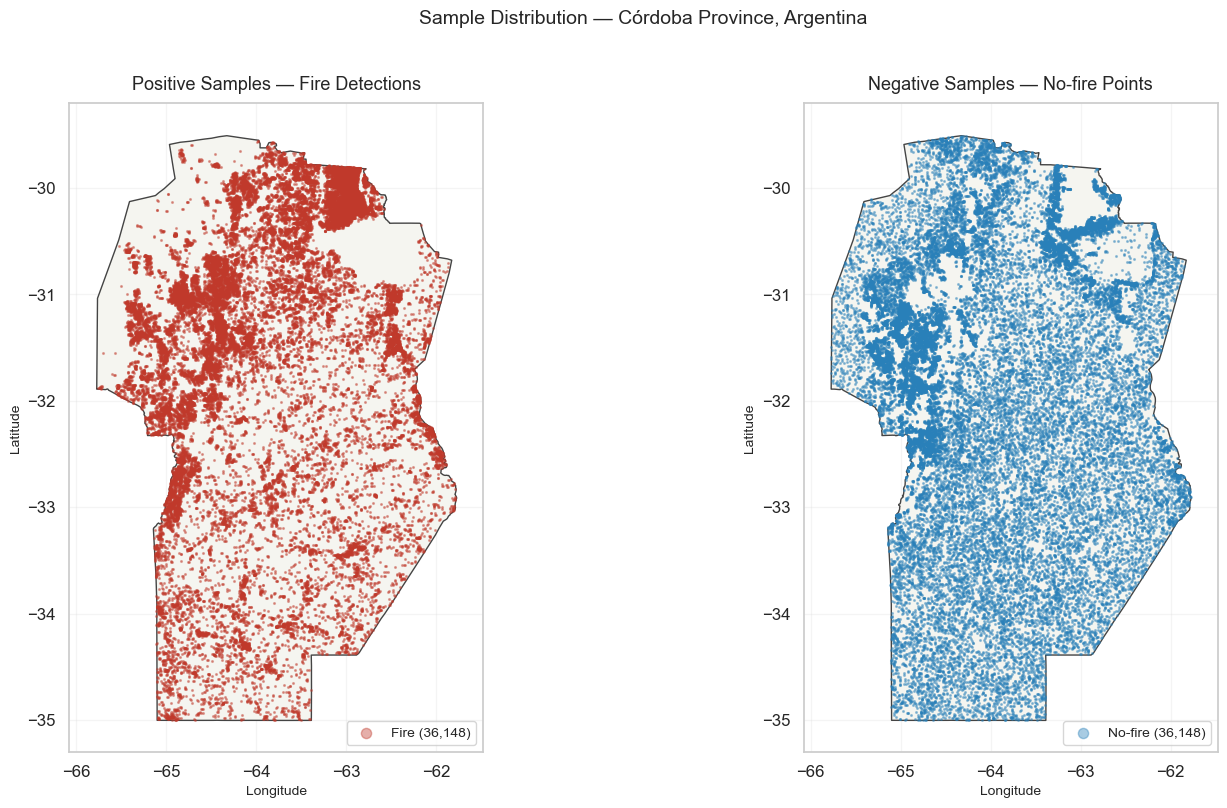

Fires  : 36,148  |  No-fire: 36,148  |  Balance: 0.5000


In [3]:
RAW = Path('../data/raw')

# Load Córdoba province boundary
boundary = gpd.read_file(RAW / 'cordoba_boundary.shp').to_crs('EPSG:4326')

# Build GeoDataFrames for fires and no-fire samples
fires   = gpd.GeoDataFrame(df[df.label == 1], geometry=gpd.points_from_xy(df[df.label==1].lon, df[df.label==1].lat), crs='EPSG:4326')
no_fire = gpd.GeoDataFrame(df[df.label == 0], geometry=gpd.points_from_xy(df[df.label==0].lon, df[df.label==0].lat), crs='EPSG:4326')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, gdf, color, label, title in [
    (axes[0], fires,   '#c0392b', f'Fire ({len(fires):,})',      'Positive Samples — Fire Detections'),
    (axes[1], no_fire, '#2980b9', f'No-fire ({len(no_fire):,})', 'Negative Samples — No-fire Points'),
]:
    boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='#444', linewidth=1.0, zorder=1)
    gdf.plot(ax=ax, color=color, markersize=1.5, alpha=0.4, zorder=2, label=label)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    ax.set_xlim(boundary.total_bounds[0] - 0.3, boundary.total_bounds[2] + 0.3)
    ax.set_ylim(boundary.total_bounds[1] - 0.3, boundary.total_bounds[3] + 0.3)
    ax.legend(markerscale=6, fontsize=10, loc='lower right')
    ax.grid(alpha=0.2)

plt.suptitle('Sample Distribution — Córdoba Province, Argentina', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_sample_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fires  : {len(fires):,}  |  No-fire: {len(no_fire):,}  |  Balance: {df.label.mean():.4f}')

## 2. Assign Spatial Block IDs

Spatial blocks (20km grid): 459 unique blocks
Samples per block — median: 114  min: 3  max: 993


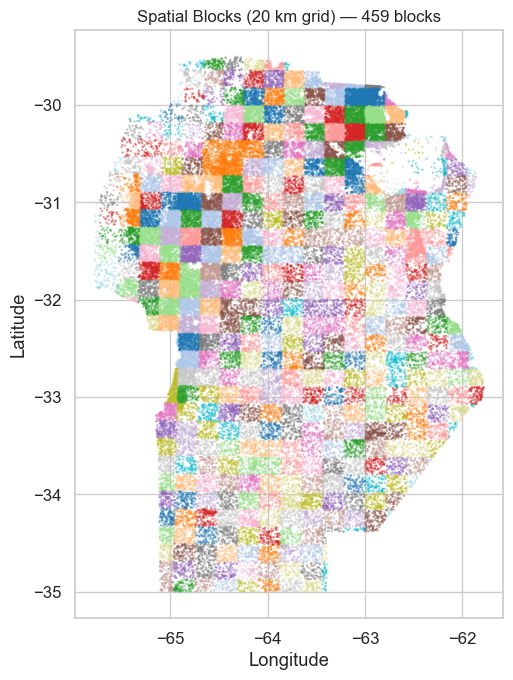

In [4]:
# Convert lat/lon to UTM 20S, snap to 20km grid → block_id
pts_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(df['lon'].values, df['lat'].values),
    crs='EPSG:4326'
).to_crs('EPSG:32720')

block_x = (pts_gdf.geometry.x // BLOCK_SIZE_M).astype(int)
block_y = (pts_gdf.geometry.y // BLOCK_SIZE_M).astype(int)
df['block_id'] = block_x.astype(str) + '_' + block_y.astype(str)

n_blocks = df['block_id'].nunique()
print(f'Spatial blocks (20km grid): {n_blocks} unique blocks')
print(f'Samples per block — median: {df.groupby("block_id").size().median():.0f}  '
      f'min: {df.groupby("block_id").size().min()}  '
      f'max: {df.groupby("block_id").size().max()}')

# Spatial distribution of blocks
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    df['lon'], df['lat'],
    c=pd.factorize(df['block_id'])[0],
    s=0.5, alpha=0.4, cmap='tab20'
)
ax.set_title(f'Spatial Blocks (20 km grid) — {n_blocks} blocks', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../outputs/v2_spatial_blocks.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. VIF-based Multicollinearity Filter

In [5]:
EXCLUDE_FROM_VIF = {'lat', 'lon', 'label', 'month', 'land_cover_class',
                    'fire_season_flag', 'block_id'}

def compute_vif(data: pd.DataFrame) -> pd.DataFrame:
    vif_data = pd.DataFrame()
    vif_data['feature'] = data.columns
    vif_data['VIF'] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)


def iterative_vif_filter(df, threshold):
    keep = [c for c in df.columns if c not in EXCLUDE_FROM_VIF]
    dropped = []
    iteration = 0
    while True:
        vif = compute_vif(df[keep])
        max_vif = vif['VIF'].max()
        if max_vif <= threshold:
            break
        worst = vif.loc[vif['VIF'].idxmax(), 'feature']
        print(f'  Iter {iteration+1}: drop "{worst}" (VIF={max_vif:.2f})')
        keep.remove(worst)
        dropped.append(worst)
        iteration += 1
    return keep, dropped


print(f'VIF filter (threshold={VIF_THRESHOLD})...')
initial_numeric = [c for c in df.columns if c not in EXCLUDE_FROM_VIF]
print(f'Initial numeric features: {len(initial_numeric)}')

initial_vif = compute_vif(df[initial_numeric])
print('\nInitial VIF values:')
print(initial_vif.to_string(index=False))

VIF filter (threshold=10.0)...
Initial numeric features: 18



Initial VIF values:
                  feature         VIF
              temperature 1366.794756
                    phh2o  603.666449
                     bdod  601.611488
                      twi  559.270575
                      vpd  429.945996
            precipitation  118.605756
                      lst   51.944806
                     ndvi   38.689447
                     clay   28.297539
               wind_speed   19.943648
                      soc   18.567346
distance_to_settlement_km    9.592960
                elevation    7.412844
                    slope    3.548219
      distance_to_road_km    2.910410
     distance_to_river_km    2.847340
       population_density    1.413284
               aspect_cos    1.098111


In [6]:
# Keep all numeric features — tree ensembles (RF/XGBoost/LightGBM) are robust
# to multicollinearity, and variables with high VIF (NDVI, temperature, LST,
# precipitation, VPD, wind speed, SOC) are physically meaningful fire predictors.
kept_features = initial_numeric
dropped_vif   = []

final_vif = compute_vif(df[kept_features])
print(f'No features dropped by VIF (informational only). Kept {len(kept_features)} features.')
print('\nVIF values (informational — no dropping applied):')
print(final_vif.to_string(index=False))

No features dropped by VIF (informational only). Kept 18 features.

VIF values (informational — no dropping applied):
                  feature         VIF
              temperature 1366.794756
                    phh2o  603.666449
                     bdod  601.611488
                      twi  559.270575
                      vpd  429.945996
            precipitation  118.605756
                      lst   51.944806
                     ndvi   38.689447
                     clay   28.297539
               wind_speed   19.943648
                      soc   18.567346
distance_to_settlement_km    9.592960
                elevation    7.412844
                    slope    3.548219
      distance_to_road_km    2.910410
     distance_to_river_km    2.847340
       population_density    1.413284
               aspect_cos    1.098111


## 4. Pairwise Correlation Filter

In [7]:
def correlation_filter(df, features, threshold):
    corr        = df[features].corr().abs()
    target_corr = df[features + ['label']].corr()['label'].abs()
    to_drop = set()
    for i, f1 in enumerate(features):
        for f2 in features[i+1:]:
            r = corr.loc[f1, f2]
            if r > threshold:
                drop = f1 if target_corr[f1] < target_corr[f2] else f2
                to_drop.add(drop)
                print(f'  Drop "{drop}" (r({f1},{f2})={r:.3f})')
    kept = [f for f in features if f not in to_drop]
    return kept, list(to_drop)


print(f'Pairwise correlation filter (threshold |r|={CORR_THRESHOLD})...')
features_after_corr, dropped_corr = correlation_filter(df, kept_features, CORR_THRESHOLD)
print(f'Dropped: {dropped_corr}')
print(f'Kept   : {features_after_corr}')

Pairwise correlation filter (threshold |r|=0.85)...
  Drop "vpd" (r(temperature,vpd)=0.853)
  Drop "bdod" (r(phh2o,bdod)=0.953)
Dropped: ['vpd', 'bdod']
Kept   : ['elevation', 'slope', 'aspect_cos', 'twi', 'ndvi', 'lst', 'temperature', 'precipitation', 'wind_speed', 'population_density', 'soc', 'clay', 'phh2o', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km']


## 5. One-Hot Encode `land_cover_class`

In [8]:
FINAL_CONTINUOUS = features_after_corr

print('land_cover_class value counts:')
print(df['land_cover_class'].value_counts().sort_index())

encoder   = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
lc_array  = encoder.fit_transform(df[['land_cover_class']])
lc_cols   = [f'lc_{int(c)}' for c in encoder.categories_[0]]
df_lc     = pd.DataFrame(lc_array, columns=lc_cols, index=df.index)

print(f'\nOHE columns ({len(lc_cols)}): {lc_cols}')

land_cover_class value counts:
land_cover_class
20.0     14676
30.0     25385
40.0     26059
50.0      1236
60.0       120
80.0       156
90.0      1538
114.0      226
116.0     1743
124.0        2
126.0     1155
Name: count, dtype: int64

OHE columns (11): ['lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


## 6. Spatial Block Train/Test Split

=== SPATIAL BLOCK TRAIN/TEST SPLIT ===
  Train: 52,904  blocks=321  fire_rate=0.5262
  Test : 19,392   blocks=138   fire_rate=0.4285
  Block overlap: 0 (expected 0)


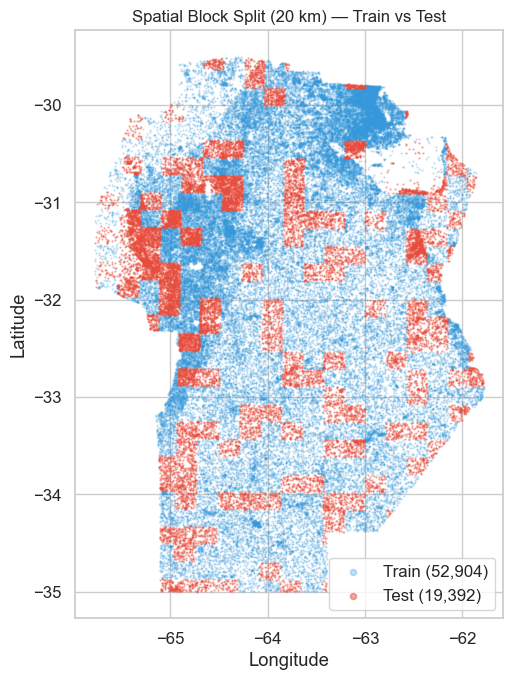

In [9]:
MODEL_FEATURES = FINAL_CONTINUOUS + lc_cols

# Assemble model-ready dataframe (unscaled — scale after split)
df_model = pd.concat([
    df[['lat', 'lon', 'label', 'block_id']].reset_index(drop=True),
    df[FINAL_CONTINUOUS].reset_index(drop=True),
    df_lc.reset_index(drop=True),
], axis=1)

# GroupShuffleSplit: no spatial block appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
groups = df_model['block_id'].values
train_idx, test_idx = next(gss.split(df_model, df_model['label'], groups=groups))

df_train = df_model.iloc[train_idx].copy().reset_index(drop=True)
df_test  = df_model.iloc[test_idx].copy().reset_index(drop=True)

# Verify no block overlap
train_blocks = set(df_train['block_id'])
test_blocks  = set(df_test['block_id'])
overlap = train_blocks & test_blocks
assert len(overlap) == 0, f'Block overlap found: {overlap}'

print('=== SPATIAL BLOCK TRAIN/TEST SPLIT ===')
print(f'  Train: {len(df_train):,}  blocks={len(train_blocks)}  '
      f'fire_rate={df_train.label.mean():.4f}')
print(f'  Test : {len(df_test):,}   blocks={len(test_blocks)}   '
      f'fire_rate={df_test.label.mean():.4f}')
print(f'  Block overlap: {len(overlap)} (expected 0)')

# Spatial plot of the split
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df_train['lon'], df_train['lat'], s=0.3, alpha=0.3,
           c='#3498db', label=f'Train ({len(df_train):,})')
ax.scatter(df_test['lon'],  df_test['lat'],  s=0.3, alpha=0.5,
           c='#e74c3c', label=f'Test ({len(df_test):,})')
ax.set_title('Spatial Block Split (20 km) — Train vs Test', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../outputs/v2_spatial_block_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. StandardScaler (fit on train only)

In [10]:
# Fit scaler on train continuous features only
scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_train[FINAL_CONTINUOUS])
test_scaled  = scaler.transform(df_test[FINAL_CONTINUOUS])

# Replace continuous features with scaled values
df_train[FINAL_CONTINUOUS] = train_scaled
df_test[FINAL_CONTINUOUS]  = test_scaled

print('StandardScaler fitted on train, applied to test.')
print(f'Train mean (should be ~0): {df_train[FINAL_CONTINUOUS].mean().round(4).values}')
print(f'Train std  (should be ~1): {df_train[FINAL_CONTINUOUS].std().round(4).values}')

StandardScaler fitted on train, applied to test.
Train mean (should be ~0): [ 0. -0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0.  0.  0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 8. Save Outputs

In [11]:
# train_v2.csv and test_v2.csv include block_id for GroupKFold in modeling
df_train.to_csv(PROCESSED / 'train_v2.csv', index=False)
df_test.to_csv(PROCESSED  / 'test_v2.csv',  index=False)
print(f'Saved train_v2.csv ({df_train.shape})  test_v2.csv ({df_test.shape})')

with open(PROCESSED / 'scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved scaler_v2.pkl')

with open(PROCESSED / 'encoder_v2.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print('Saved encoder_v2.pkl')

feature_meta_v2 = {
    'continuous_features'   : FINAL_CONTINUOUS,
    'landcover_ohe_features': lc_cols,
    'all_model_features'    : MODEL_FEATURES,
    'dropped_vif'           : dropped_vif,
    'dropped_correlation'   : dropped_corr,
    'vif_threshold'         : VIF_THRESHOLD,
    'corr_threshold'        : CORR_THRESHOLD,
    'block_size_km'         : BLOCK_SIZE_M / 1000,
    'pop_density_impute_median': float(pop_median),
}
with open(PROCESSED / 'selected_features_v2.json', 'w') as f:
    json.dump(feature_meta_v2, f, indent=2)
print('Saved selected_features_v2.json')

Saved train_v2.csv ((52904, 31))  test_v2.csv ((19392, 31))
Saved scaler_v2.pkl
Saved encoder_v2.pkl
Saved selected_features_v2.json


## 9. Verification

In [12]:
print('=== PREPROCESSING V2 VERIFICATION ===')

# No NaN
assert df_train.isnull().sum().sum() == 0
assert df_test.isnull().sum().sum()  == 0
print('  [OK] No NaN in train_v2 / test_v2')

# VIF informational only (no assertion — multicollinearity accepted for tree ensembles)
print(f'  [INFO] Max VIF (informational) = {final_vif["VIF"].max():.2f}'
      f'  (no filter applied — tree ensembles handle multicollinearity)')

# Pairwise correlation
corr_arr = df[FINAL_CONTINUOUS].corr().abs().to_numpy().copy()
np.fill_diagonal(corr_arr, 0)
max_corr = corr_arr.max()
assert max_corr <= CORR_THRESHOLD
print(f'  [OK] Max pairwise |r| = {max_corr:.3f} <= {CORR_THRESHOLD}')

# No block overlap
assert len(set(df_train['block_id']) & set(df_test['block_id'])) == 0
print(f'  [OK] No spatial block overlap between train and test')

# Files exist
for fname in ['train_v2.csv', 'test_v2.csv', 'scaler_v2.pkl',
              'encoder_v2.pkl', 'selected_features_v2.json']:
    assert (PROCESSED / fname).exists()
print('  [OK] All output files saved')

print(f'\nFinal features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

=== PREPROCESSING V2 VERIFICATION ===
  [OK] No NaN in train_v2 / test_v2
  [INFO] Max VIF (informational) = 1366.79  (no filter applied — tree ensembles handle multicollinearity)
  [OK] Max pairwise |r| = 0.841 <= 0.85
  [OK] No spatial block overlap between train and test
  [OK] All output files saved

Final features (27): ['elevation', 'slope', 'aspect_cos', 'twi', 'ndvi', 'lst', 'temperature', 'precipitation', 'wind_speed', 'population_density', 'soc', 'clay', 'phh2o', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']
